In [8]:
!pip install scikit-learn


                                              0.0/11.1 MB ? eta -:--:--
                                              0.0/11.1 MB 1.3 MB/s eta 0:00:09
                                              0.1/11.1 MB 1.1 MB/s eta 0:00:11
                                              0.2/11.1 MB 1.2 MB/s eta 0:00:09
                                              0.2/11.1 MB 1.2 MB/s eta 0:00:09
                                              0.2/11.1 MB 1.3 MB/s eta 0:00:09
     -                                        0.3/11.1 MB 1.4 MB/s eta 0:00:09
     -                                        0.3/11.1 MB 1.2 MB/s eta 0:00:09
     -                                        0.5/11.1 MB 1.3 MB/s eta 0:00:08
     -                                        0.6/11.1 MB 1.3 MB/s eta 0:00:08
     --                                       0.6/11.1 MB 1.4 MB/s eta 0:00:08
     --                                       0.7/11.1 MB 1.4 MB/s eta 0:00:08
     --                                       0.8/11.1 MB 1


[notice] A new release of pip is available: 23.1.2 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib
import streamlit as st
import joblib

In [11]:
# 1. Load dataset
df = pd.read_csv('student_final_grade_dataset.csv')
print(df.head())


  Student_ID  Attendance_Rate  Assignment_Score_Avg  Quiz_Score_Avg  \
0      S0001        89.967142             81.502694       64.173937   
1      S0002        83.617357             74.847134       77.652313   
2      S0003        91.476885             81.467570       66.799799   
3      S0004       100.000000             86.519576       70.925173   
4      S0005        82.658466             80.586321      100.000000   

   Midterm_Score  Participation_Level  Study_Hours_Per_Week  \
0      53.521290                    3              8.859281   
1      55.617811                    5             12.494669   
2     100.000000                    3             13.691787   
3      70.013656                    2              7.037110   
4      85.642600                    2             12.102086   

  Parental_Education_Level Internet_Access Extracurricular_Activities  \
0               HighSchool             Yes                        Yes   
1               HighSchool             Yes      

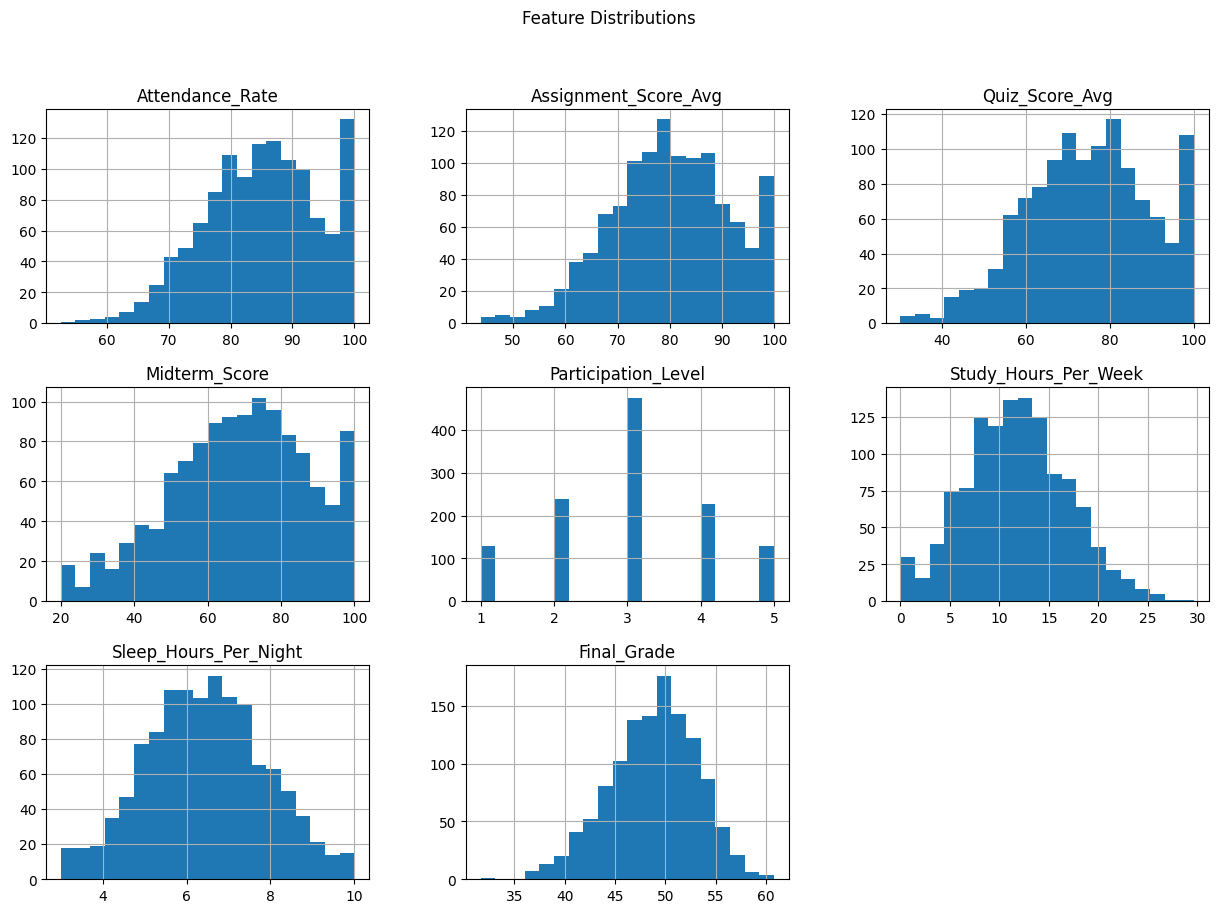

In [12]:
# Histograms
df.hist(bins=20, figsize=(15, 10))
plt.suptitle('Feature Distributions')
plt.show()


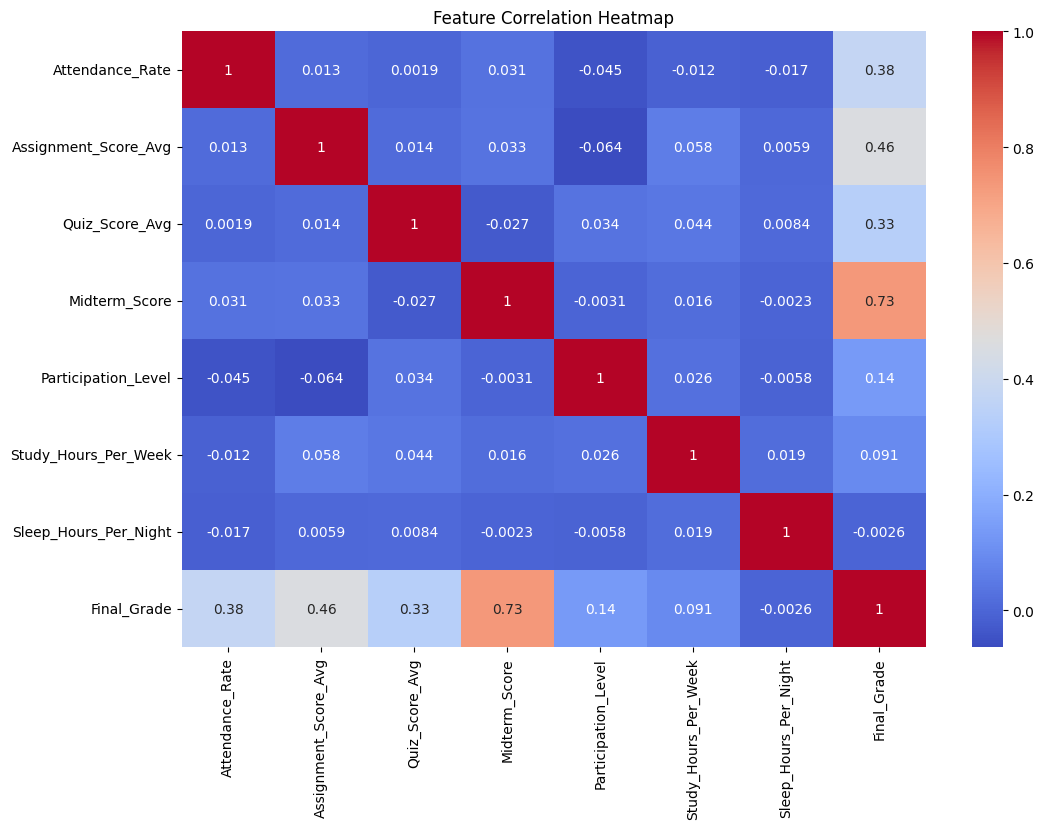

In [13]:
# Correlation Heatmap (after dropping non-numeric manually)
df_for_corr = df.drop(columns=["Student_ID", "Parental_Education_Level", "Internet_Access", "Extracurricular_Activities"])
numeric_df = df_for_corr.select_dtypes(include=[np.number])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()


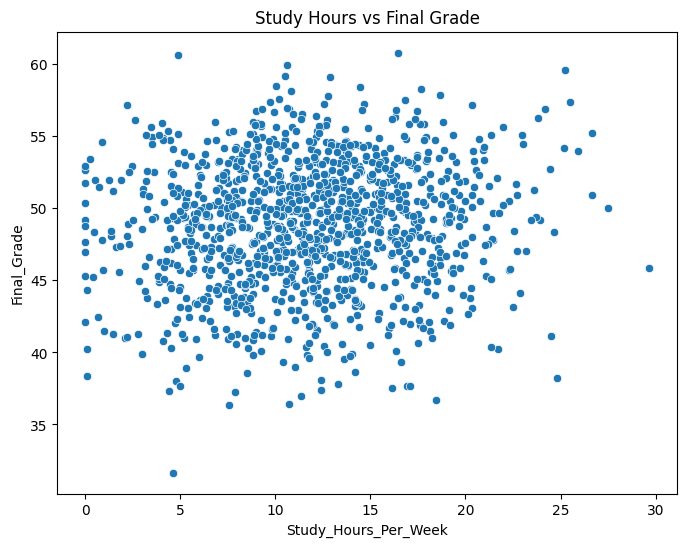

In [14]:
# Scatter Plot: Study Hours vs Final Grade
plt.figure(figsize=(8,6))
sns.scatterplot(x='Study_Hours_Per_Week', y='Final_Grade', data=df)
plt.title('Study Hours vs Final Grade')
plt.show()

In [15]:
# 3. Data Preprocessing
df_encoded = pd.get_dummies(df, columns=["Parental_Education_Level", "Internet_Access", "Extracurricular_Activities"], drop_first=True)
X = df_encoded.drop(columns=["Student_ID", "Final_Grade"])
y = df_encoded["Final_Grade"]

In [16]:
# 4. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

In [18]:
print("Linear Regression R2:", r2_score(y_test, lr_preds))
print("Linear Regression MAE:", mean_absolute_error(y_test, lr_preds))

Linear Regression R2: 0.9999995709142903
Linear Regression MAE: 0.0026507471510772264


In [19]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

In [20]:
print("Random Forest R2:", r2_score(y_test, rf_preds))
print("Random Forest MAE:", mean_absolute_error(y_test, rf_preds))

Random Forest R2: 0.9444483067574461
Random Forest MAE: 0.855203750000001


In [21]:

# Analyze feature importances from the Random Forest model
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df)

# Check for potential issues:
# 1. Overfitting:
#    - Compare training and testing MAE/R2 scores. A large gap suggests overfitting.
print("Random Forest Training MAE:", mean_absolute_error(y_train, rf_model.predict(X_train)))

# 2. Feature Engineering:
#    - Examine the feature importance scores.  Are there any features with very low importance?
#    - Consider creating new features or transforming existing ones to improve model performance.

# 3. Hyperparameter Tuning:
#   - Experiment with different hyperparameters (n_estimators, max_depth, min_samples_split, etc.) for the RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='neg_mean_absolute_error')
grid_search.fit(X_train, y_train)

print("Best hyperparameters:", grid_search.best_params_)
print("Best MAE:", -grid_search.best_score_) # negate because scoring is neg_mean_absolute_error

best_rf_model = grid_search.best_estimator_
best_rf_preds = best_rf_model.predict(X_test)
print("Best Random Forest R2:", r2_score(y_test, best_rf_preds))
print("Best Random Forest MAE:", mean_absolute_error(y_test, best_rf_preds))





                                Feature  Importance
3                         Midterm_Score    0.550919
1                  Assignment_Score_Avg    0.189828
0                       Attendance_Rate    0.113707
2                        Quiz_Score_Avg    0.109456
4                   Participation_Level    0.011968
5                  Study_Hours_Per_Week    0.010024
6                 Sleep_Hours_Per_Night    0.007871
7   Parental_Education_Level_HighSchool    0.001772
11       Extracurricular_Activities_Yes    0.001558
8      Parental_Education_Level_Masters    0.001308
9          Parental_Education_Level_PhD    0.000831
10                  Internet_Access_Yes    0.000759
Random Forest Training MAE: 0.32365781249999953
Best hyperparameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best MAE: 0.898240520833333
Best Random Forest R2: 0.9439317744320355
Best Random Forest MAE: 0.8632972916666674


In [22]:
# 7. Save the Best Model
best_model = rf_model  # Assuming Random Forest performs better
joblib.dump(best_model, 'final_grade_predictor_model.pkl')
print("Model saved successfully!")

Model saved successfully!


In [23]:
# Load the model
model = joblib.load('final_grade_predictor_model.pkl')

st.title("Student Final Grade Predictor")

# User Inputs
attendance = st.slider('Attendance Rate (%)', 50, 100, 85)
assignment_score = st.slider('Assignment Score Average (%)', 40, 100, 80)
quiz_score = st.slider('Quiz Score Average (%)', 30, 100, 75)
midterm_score = st.slider('Midterm Score (%)', 20, 100, 70)
participation = st.slider('Participation Level (1-5)', 1, 5, 3)
study_hours = st.slider('Study Hours Per Week', 0, 30, 12)
parent_education = st.selectbox('Parental Education Level', ['HighSchool', 'Bachelors', 'Masters', 'PhD'])
internet = st.selectbox('Internet Access', ['Yes', 'No'])
extracurricular = st.selectbox('Participates in Extracurricular Activities', ['Yes', 'No'])
sleep_hours = st.slider('Sleep Hours Per Night', 3, 10, 6)

# Encoding categorical features manually
parent_edu_cols = ['Parental_Education_Level_Bachelors', 'Parental_Education_Level_Masters', 'Parental_Education_Level_PhD']
internet_col = ['Internet_Access_Yes']
extra_col = ['Extracurricular_Activities_Yes']

parent_edu = [0,0,0]
if parent_education == "Bachelors":
    parent_edu[0] = 1
elif parent_education == "Masters":
    parent_edu[1] = 1
elif parent_education == "PhD":
    parent_edu[2] = 1

internet_val = [1] if internet == "Yes" else [0]
extra_val = [1] if extracurricular == "Yes" else [0]

# Final input for model
input_features = np.array([attendance, assignment_score, quiz_score, midterm_score, participation,
                            study_hours, sleep_hours] + parent_edu + internet_val + extra_val).reshape(1, -1)

# Prediction
if st.button('Predict Final Grade'):
    prediction = model.predict(input_features)
    st.success(f"Predicted Final Grade: {prediction[0]:.2f}%")

2025-04-28 13:20:21.278 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-28 13:20:22.007 
  command:

    streamlit run C:\Users\Ayesha Siddika\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-04-28 13:20:22.011 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-28 13:20:22.012 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-28 13:20:22.013 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-28 13:20:22.014 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-28 13:20:22.017 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-28 13:20:22